In [33]:
def get_top_keywords(url: str, k: int = 10, return_details: bool = False):
    import re
    import urllib.request
    from urllib.parse import urlparse
    from collections import Counter
    from bs4 import BeautifulSoup, Comment
    from nltk.corpus import stopwords
    import nltk
    import requests

    # --------------------- ensure NLTK data ---------------------
    try:
        stopwords.words("english")
    except LookupError:
        nltk.download("stopwords")

    # --------------------- ensure Finnish stemmer ---------------------
    try:
        from nltk.stem.snowball import SnowballStemmer
    except ImportError:
        nltk.download('snowball_data')
        from nltk.stem.snowball import SnowballStemmer

    # --------------------- ensure langdetect is installed ---------------------
    try:
        from langdetect import detect
    except ImportError:
        import subprocess
        subprocess.check_call(["pip", "install", "langdetect"])
        from langdetect import detect

    # --------------------- config ---------------------
    COMMON_NOISE_WORDS = set("""
    January debt est dec big than who use jun jan feb mar apr may jul august dec oct nov sep dec
    product continue one two three four five please thanks find helpful week job experience women girl
    apology read show eve knowledge benefit appointment street way staff salon discount gift cost thing
    world close party love letters rewards offers special close pack wed dollars voucher gifts vouchers
    welcome therefore march nights need name please show sisters thank menu today always time needs
    welcome march february april may june jully august september october november december day year
    month minute second seconds
    """.split())
    my_noise_words_india = set(
        {
            "bangkok",
            "tuli",
            "bengal",
            "hurm",
            "keitinpiir",
            "uutiskirj",
            "kera",
            "itsenäisyyspäiv",
            "paahtopai",
            "alkoholittom",
            "lämmittäv",
            "uusim",
            "lihavok",
            "tila",
            "savuin",
            "valmistetu",
            "viera",
            "lihacury",
            "jättilihapul",
            "kampasimpuko",
            "heinäkasaperun",
            "aineks",
            "nauta",
            "puolukkashot",
            "japanilaistyylin",
            "muscovado",
            "erit",
            "täyteläin",
            "kurpitsariesk",
            "aasialaisit",
            "vuode",
            "toimitus",
            "teko",
            "menu",
            "mediatiedo",
            "nino",
            "lämpö",
            "jäädäks",
            "limemarinoidu",
            "herkul",
            "dick",
            "hunaj",
            "koto",
            "munacury",
            "vaivato",
            "kastik",
            "pommac",
            "paahtaj",
            "mehev",
            "suosittel",
            "keitety",
            "karamelliomeno",
            "leivo",
            "sienipiirak",
            "eli",
            "hirvikaud",
            "voita",
            "malesialain",
            "simo",
            "korm",
            "karitsanpotk",
            "puoluko",
            "ääne",
            "mausteöljy",
            "vaalea",
            "kof",
            "pastakastik",
            "hallikaupia",
            "koko",
            "grillileik",
            "tuoksu",
            "tuot",
            "lohicarpacio",
            "bloge",
            "expres",
            "nap",
            "italialais",
            "kolm",
            "hurmaav",
            "broilerinleik",
            "komment",
            "lue",
            "peking",
            "kup",
            "asiakaspalvelu",
            "vastaus",
            "italial",
            "maukas",
            "lihapullacury",
            "lisä",
            "olkiperuno",
            "bataattikeito",
            "tervetulo",
            "sobanuudelisalaat",
            "balsamicokastik",
            "täytety",
            "jäätelökonekes",
            "sitruunak",
            "tapaks",
            "marinoidu",
            "korvasienikastik",
            "resept",
            "pada",
            "make",
            "tapa",
            "punain",
            "kahd",
            "kasvist",
            "keskustelu",
            "hapattim",
            "pikalei",
            "reikälei",
            "raikas",
            "maustein",
            "herku",
            "suositu",
            "vink",
            "kokonaispist",
            "höyrytety",
            "valkosipulilei",
        }
    )
    my_noise_words_india_2nd_set = set()

    # Finnish-specific noise words (site navigation, UI elements, etc.)
    finnish_noise_words = set("""
    blogit kommentit kommentoi peruuta avainsanat tunnisteet valmistusohje ainekset menu
    ruokalista viikon helpot herkulliset arkiruoat juhlamenu mukana maku pippurimylly
    yrttiopas myös
    """.split())

    # Mapping from langdetect language codes to NLTK stopwords language names
    LANG_CODE_TO_NLTK = {
        'af': 'afrikaans',
        'ar': 'arabic',
        'bg': 'bulgarian',
        'bn': 'bengali',
        'ca': 'catalan',
        'cs': 'czech',
        'cy': 'welsh',
        'da': 'danish',
        'de': 'german',
        'el': 'greek',
        'en': 'english',
        'es': 'spanish',
        'et': 'estonian',
        'fa': 'persian',
        'fi': 'finnish',
        'fr': 'french',
        'gu': 'gujarati',
        'he': 'hebrew',
        'hi': 'hindi',
        'hu': 'hungarian',
        'id': 'indonesian',
        'it': 'italian',
        'ja': 'japanese',
        'kn': 'kannada',
        'ko': 'korean',
        'lt': 'lithuanian',
        'lv': 'latvian',
        'mk': 'macedonian',
        'ml': 'malayalam',
        'mr': 'marathi',
        'ne': 'nepali',
        'nl': 'dutch',
        'no': 'norwegian',
        'pa': 'punjabi',
        'pl': 'polish',
        'pt': 'portuguese',
        'ro': 'romanian',
        'ru': 'russian',
        'sk': 'slovak',
        'sl': 'slovenian',
        'so': 'somali',
        'sq': 'squarish',
        'sv': 'swedish',
        'ta': 'tamil',
        'te': 'telugu',
        'th': 'thai',
        'tl': 'tagalog',
        'tr': 'turkish',
        'uk': 'ukrainian',
        'vi': 'vietnamese',
        'zh-cn': 'chinese_simplified',
        'zh-tw': 'chinese_traditional',
    }

    # --------------------- helpers ---------------------
    def _normalize_finnish_word(word, detected_lang='finnish'):
        """Normalize Finnish words using stemming"""
        word = word.lower()
        if detected_lang == 'finnish':
            try:
                stemmer = SnowballStemmer('finnish')
                return stemmer.stem(word)
            except:
                return word
        return word

    def _is_visible_text(element) -> bool:
        if element.parent.name in ["html", "style", "script", "head", "[document]", "img"]:
            return False
        if isinstance(element, Comment):
            return False
        return True

    def _extract_visible_text_from_html(html: bytes) -> str:
        soup = BeautifulSoup(html, "lxml")
        texts = soup.find_all(string=True)
        visible_texts = filter(_is_visible_text, texts)
        return " ".join(t.strip() for t in visible_texts)

    def _normalize_whitespace(text: str) -> str:
        lines = (line.strip() for line in text.splitlines())
        chunks = (phrase.strip() for line in lines for phrase in line.split("  "))
        return "\n".join(chunk for chunk in chunks if chunk)

    def _fetch_page(u: str):
        headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
        }
        response = requests.get(u, headers=headers, timeout=20)
        response.raise_for_status()
        html = response.content

        soup = BeautifulSoup(html, "lxml")
        raw_text = _extract_visible_text_from_html(html)
        clean_text = _normalize_whitespace(raw_text)
        return clean_text, soup

    def _detect_language_and_stopwords(text: str):
        """Detect language using langdetect and return appropriate stopwords"""
        try:
            # Use langdetect to detect language
            lang_code = detect(text)

            # Map language code to NLTK language name
            nltk_lang = LANG_CODE_TO_NLTK.get(lang_code, 'english')

            # Try to get stopwords for detected language
            try:
                sw = set(stopwords.words(nltk_lang))
                # print(f"Detected language: {nltk_lang} (code: {lang_code})")
                return nltk_lang, sw
            except Exception:
                # If stopwords not available for detected language, fall back to English
                print(f"Detected language: {nltk_lang} (code: {lang_code}), but no stopwords available. Using English.")
                return "english", set(stopwords.words("english"))

        except Exception as e:
            # If detection fails, fall back to English
            print(f"Language detection failed ({e}). Using English.")
            return "english", set(stopwords.words("english"))

    def _clean_text_to_words(text: str, stopword_list: set, detected_lang: str = 'english') -> list:
        words = []
        LETTERS_ONLY_RE = re.compile(r"[^a-zA-ZåäöÅÄÖ]+")

        for raw_word in text.split():
            token = LETTERS_ONLY_RE.sub("", raw_word).lower()

            if (
                len(token) > 1
                and not token[0].isdigit()
                and token not in stopword_list
                # and token not in COMMON_NOISE_WORDS
                and token not in my_noise_words_india
                and token not in finnish_noise_words
                # and token not in my_noise_words_india_2nd_set
                and not token.isdigit()
            ):
                # Normalize (stem for Finnish)
                normalized_token = _normalize_finnish_word(token, detected_lang)
                words.append(normalized_token)

        return words

    def _split_url_host(u: str) -> list:
        parsed = urlparse(u)
        host = parsed.hostname or ""
        parts = []
        for chunk in host.split("."):
            chunk = chunk.lower()
            if chunk not in ["", "https", "www", "com", "-", "php", "pk", "fi", "http"]:
                parts.append(chunk)
        return parts

    def _split_url_path_and_query(u: str, host_parts: list) -> list:
        path_tokens = []
        for segment in u.split("/"):
            for dot_part in segment.split("."):
                for dash_part in dot_part.split("-"):
                    token = dash_part.lower()
                    if (
                        token
                        and token not in [
                            "https", "www", "com", "-", "php", "pk", "fi",
                            "https:", "http", "http:", "http:",
                        ]
                        and token not in host_parts
                    ):
                        path_tokens.append(token)
        return path_tokens

    def _extract_tag_texts(soup, tag_name: str) -> list:
        out = []
        for el in soup.find_all(tag_name):
            t = el.get_text(strip=True).lower()
            if t:
                out.append(t)
        return out

    def _explode_texts_to_words(text_list: list, detected_lang: str = 'english') -> list:
        out = []
        for text in text_list:
            for comma_chunk in text.split(","):
                for w in comma_chunk.split():
                    # Normalize (stem for Finnish)
                    normalized_w = _normalize_finnish_word(w, detected_lang)
                    out.append(normalized_w)
        return out

    def _extract_headers_anchors_title_words(soup, detected_lang: str = 'english'):
        h1 = _explode_texts_to_words(_extract_tag_texts(soup, "h1"), detected_lang)
        h2 = _explode_texts_to_words(_extract_tag_texts(soup, "h2"), detected_lang)
        h3 = _explode_texts_to_words(_extract_tag_texts(soup, "h3"), detected_lang)
        h4 = _explode_texts_to_words(_extract_tag_texts(soup, "h4"), detected_lang)
        h5 = _explode_texts_to_words(_extract_tag_texts(soup, "h5"), detected_lang)
        h6 = _explode_texts_to_words(_extract_tag_texts(soup, "h6"), detected_lang)
        a = _explode_texts_to_words(_extract_tag_texts(soup, "a"), detected_lang)
        ti = _explode_texts_to_words(_extract_tag_texts(soup, "title"), detected_lang)
        return h1, h2, h3, h4, h5, h6, a, ti

    def _tf_score(freq: int, total_tokens: int) -> float:
        # Keep your original behavior
        if total_tokens < 50:
            return (freq / 100.0) * 50
        else:
            return (freq / 100.0) * 20

    def _compute_keyword_scores(words: list, soup, u: str, detected_lang: str = 'english') -> dict:
        freq = Counter(words)
        total_tokens = len(words)

        h1, h2, h3, h4, h5, h6, anchor, title = _extract_headers_anchors_title_words(soup, detected_lang)
        url_host = _split_url_host(u)
        url_path = _split_url_path_and_query(u, url_host)

        headers_names = ["H1", "H2", "H3", "H4", "H5", "H6", "A", "Title", "URL-H", "URL-Q"]
        headers_scores = [6, 5, 4, 3, 2, 2, 1, 5, 5, 4]
        headers_lists = [h1, h2, h3, h4, h5, h6, anchor, title, url_host, url_path]

        word_info = {}  # word -> (freq, [tags], final_score)
        for w, c in freq.items():
            base = _tf_score(c, total_tokens)
            tag_boost, tag_names = 0.0, []
            for idx, toks in enumerate(headers_lists):
                if w in toks:
                    tag_boost += headers_scores[idx]
                    tag_names.append(headers_names[idx])
            word_info[w] = (c, tag_names, base + tag_boost)

        return word_info

    # --------------------- pipeline ---------------------
    clean_text, soup = _fetch_page(url)
    detected_lang, stopword_list = _detect_language_and_stopwords(clean_text)
    tokens = _clean_text_to_words(clean_text, stopword_list, detected_lang)

    if not tokens:
        return [] if not return_details else []

    keyword_data = _compute_keyword_scores(tokens, soup, url, detected_lang)
    top = sorted(keyword_data.items(), key=lambda kv: kv[1][2], reverse=True)[:k]

    if return_details:
        # [(word, freq, score, tags), ...]
        return [(w, meta[0], meta[2], meta[1]) for w, meta in top]
    else:
        # [word, ...]
        return [w for w, _ in top]

In [34]:
# --------------------- evaluation (Ruoka.fi - Online) ---------------------

import urllib.request
import matplotlib.pyplot as plt
import numpy as np

# Use online dataset
BASE = "https://cs.uef.fi/~himat/WebRank/dataset_12/dataset_12/ruoka/"

# Import Finnish stemmer
from nltk.stem.snowball import SnowballStemmer

def _normalize_finnish_word_eval(word):
    """Normalize Finnish words using stemming"""
    word = word.lower()
    try:
        stemmer = SnowballStemmer('finnish')
        return stemmer.stem(word)
    except:
        return word

def Get_Prc_Rcl_Fscr_input_GT_and_Keywords_List(ground_truth, keywords):
    matches = [(word, ground_truth.count(word)) for word in ground_truth if word in keywords]

    ground_truth_count = len(ground_truth)
    keywords_count = len(keywords)
    match_count = len(matches)

    if ground_truth_count == 0 or keywords_count == 0:
        return (0, 0, 0, [])

    precision = match_count / keywords_count
    recall = match_count / ground_truth_count

    if precision + recall == 0:
        return (0, 0, 0, [])

    f_score = (2 * precision * recall) / (precision + recall)
    return (precision, recall, f_score, matches)


def Make_score_round_and_divide(precision_sum, recall_sum, fscore_sum, total_webpages):
    avg_precision = round(precision_sum / total_webpages, 2)
    avg_recall = round(recall_sum / total_webpages, 2)
    avg_fscore = round(fscore_sum / total_webpages, 2)
    return (avg_precision, avg_recall, avg_fscore)


def read_url(url):
    with urllib.request.urlopen(url) as f:
        return f.read().decode("utf-8-sig").strip()


def load_ruoka_case(index):
    """Load a test case from online ruoka dataset"""
    base = f"{BASE}{index}"
    
    # Read URL.txt (for reference, though we won't use it)
    # url_text = read_url(f"{base}/URL.txt")
    
    # Read GT.txt
    gt_text = read_url(f"{base}/GT.txt")
    gt_tokens = gt_text.lower().split()
    # Stem ground truth tokens to match extracted keywords
    gt_tokens_stemmed = [_normalize_finnish_word_eval(token) for token in gt_tokens]
    
    # Fetch HTML from the server's stored copy (not from the original URL)
    html_url = f"{base}/"  # This will fetch the index.html
    
    return html_url, gt_tokens_stemmed

def my_debug(URL, gt_keywords, drank_keywords, matches, p, r, f):
    print("URL:", URL)
    print("Ground Truth Keywords:", gt_keywords)
    print("Extracted Keywords:", drank_keywords)
    print("Matches:", matches)
    print("Precision:", p, "Recall:", r, "F-score:", f)

def Score_evaluation(total_webpages):
    precision_sum = 0.0
    recall_sum = 0.0
    fscore_sum = 0.0
    
    # Store metrics for each webpage
    webpage_ids = []
    precisions = []
    recalls = []
    fscores = []
    total_gt = []
    total_kw = []

    for i in range(total_webpages):
        URL, gt_keywords = load_ruoka_case(str(i))
        drank_keywords = get_top_keywords(URL, k=15)    
        total_gt.extend(gt_keywords)
        total_kw.extend(drank_keywords)

        p, r, f, matches = Get_Prc_Rcl_Fscr_input_GT_and_Keywords_List(gt_keywords, drank_keywords)
        # my_debug(URL, gt_keywords, drank_keywords, matches, p, r, f)
        
        # Store for graphing
        webpage_ids.append(i)
        precisions.append(p)
        recalls.append(r)
        fscores.append(f)
        
        precision_sum += p
        recall_sum += r
        fscore_sum += f

    return precision_sum, recall_sum, fscore_sum, webpage_ids, precisions, recalls, fscores, total_gt, total_kw

total_webpages = 10
precision_sum, recall_sum, fscore_sum, webpage_ids, precisions, recalls, fscores, total_gt, total_kw = Score_evaluation(total_webpages)

avg_p, avg_r, avg_f = Make_score_round_and_divide(
    precision_sum, recall_sum, fscore_sum, total_webpages
)

print("=== AVERAGE OVER ALL WEBPAGES ===")
print("Average Precision:", avg_p)
print("Average Recall   :", avg_r)
print("Average F-score  :", avg_f)

# print("\n=== ALL GROUND TRUTH KEYWORDS (FLATTENED) ===")
# print(f"Total count: {len(total_gt)}")
# print(total_gt)

# print("\n=== ALL EXTRACTED KEYWORDS (FLATTENED) ===")
# print(f"Total count: {len(total_kw)}")
# print(total_kw)

print("\n=== Noise Words in Extracted Keywords (not in GT) ===")
noise_words = [word for word in total_kw if word not in total_gt]
print(f"Total noise words: {len(noise_words)}")
print(set(noise_words))
print(f"Total unique noise words: {len(set(noise_words))}")


=== AVERAGE OVER ALL WEBPAGES ===
Average Precision: 0.13
Average Recall   : 0.26
Average F-score  : 0.17

=== Noise Words in Extracted Keywords (not in GT) ===
Total noise words: 121
{'lämpö', 'tarjottav', 'ääne', 'tervetulo', 'hurm', 'jäätelökonekes', 'herkul', 'tapaks', 'kone', 'uutiskirj', 'resept', 'pada', 'koko', 'koto', 'espanj', 'vaivato', 'bloge', 'make', 'pippurimyly', 'alkoholittom', 'uusim', 'pommac', 'tila', 'nap', 'keskustelu', 'lindertz', 'paahtaj', 'suosittel', 'mehev', 'viera', 'leivo', 'nauta', 'komment', 'japanilaistyylin', 'maustein', 'herku', 'suositu', 'teko', 'vink', 'kokonaispist', 'menu', 'uunir', 'valkosipulilei', 'focacia', 'italial'}
Total unique noise words: 45


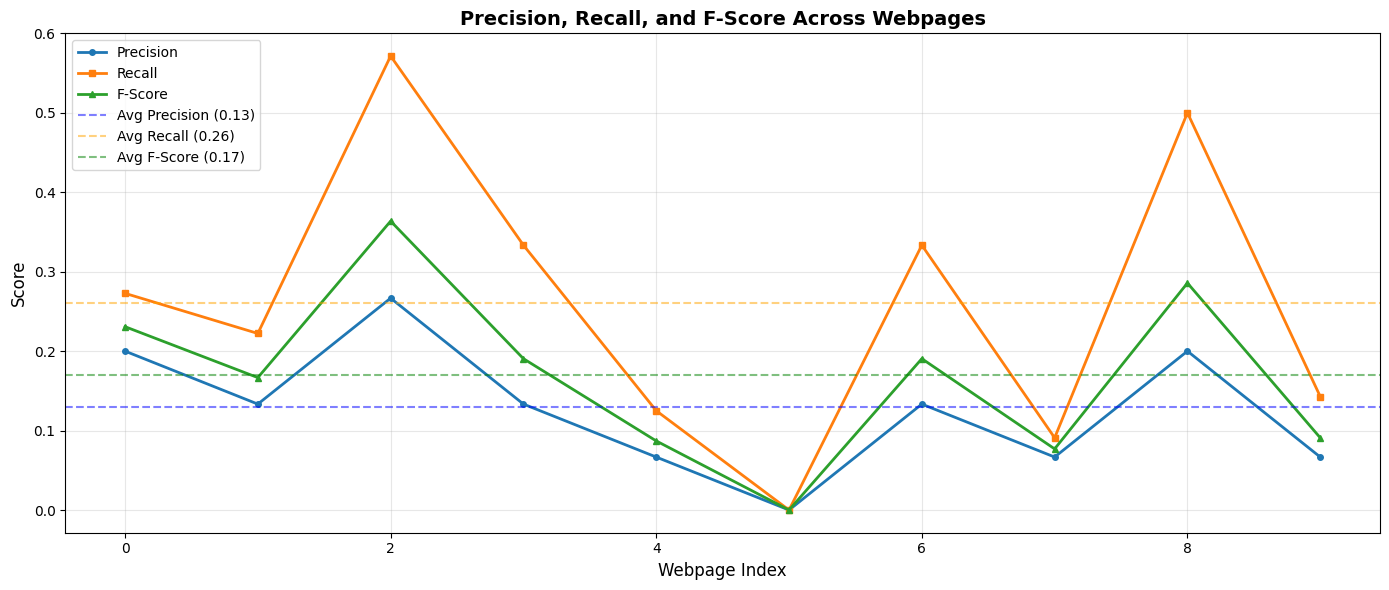

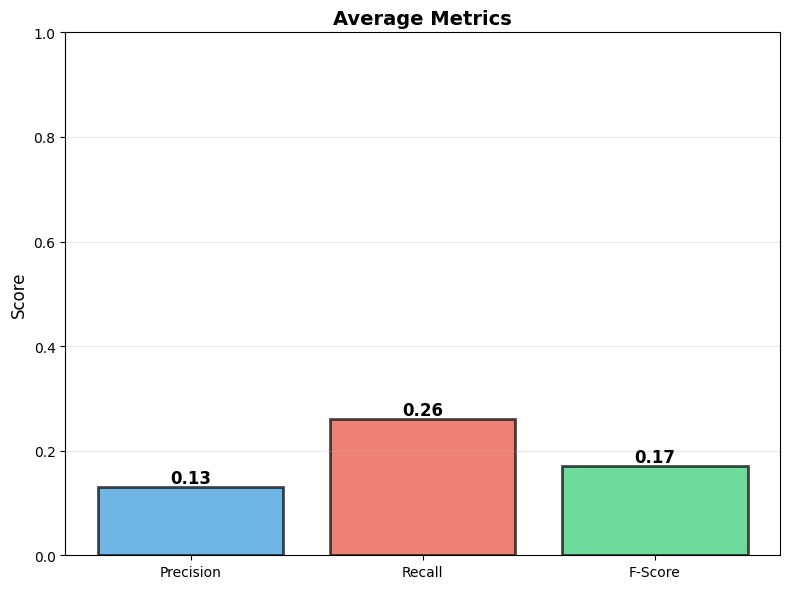

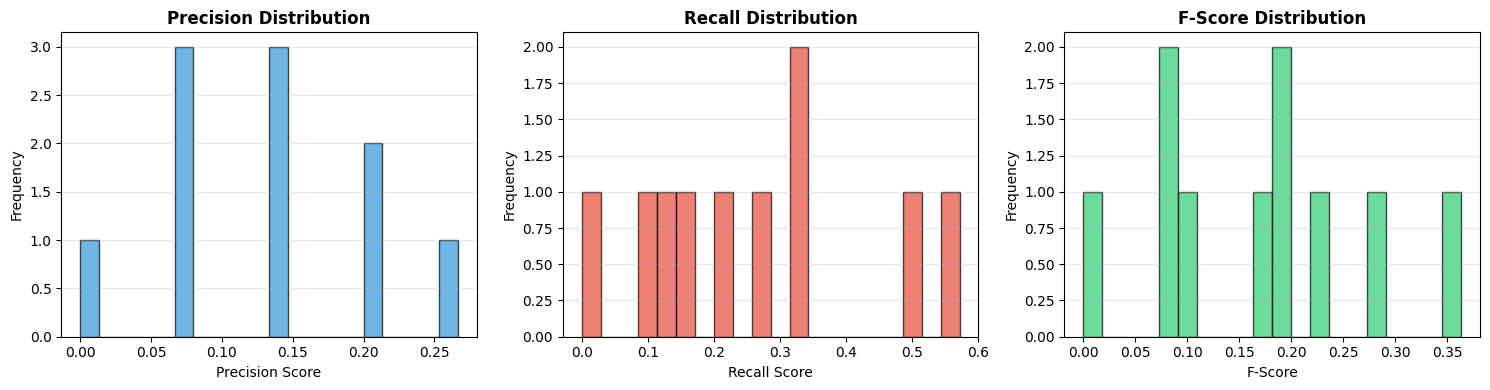

In [35]:
# --------------------- Visualization ---------------------

# Plot 1: Line chart of P, R, F-score across webpages
plt.figure(figsize=(14, 6))
plt.plot(webpage_ids, precisions, marker='o', label='Precision', linewidth=2, markersize=4)
plt.plot(webpage_ids, recalls, marker='s', label='Recall', linewidth=2, markersize=4)
plt.plot(webpage_ids, fscores, marker='^', label='F-Score', linewidth=2, markersize=4)

plt.axhline(y=avg_p, color='blue', linestyle='--', alpha=0.5, label=f'Avg Precision ({avg_p})')
plt.axhline(y=avg_r, color='orange', linestyle='--', alpha=0.5, label=f'Avg Recall ({avg_r})')
plt.axhline(y=avg_f, color='green', linestyle='--', alpha=0.5, label=f'Avg F-Score ({avg_f})')

plt.xlabel('Webpage Index', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Precision, Recall, and F-Score Across Webpages', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Bar chart of averages
fig, ax = plt.subplots(figsize=(8, 6))
metrics = ['Precision', 'Recall', 'F-Score']
values = [avg_p, avg_r, avg_f]
colors = ['#3498db', '#e74c3c', '#2ecc71']

bars = ax.bar(metrics, values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Average Metrics', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Plot 3: Distribution histogram
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(precisions, bins=20, color='#3498db', alpha=0.7, edgecolor='black')
axes[0].set_title('Precision Distribution', fontweight='bold')
axes[0].set_xlabel('Precision Score')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].hist(recalls, bins=20, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1].set_title('Recall Distribution', fontweight='bold')
axes[1].set_xlabel('Recall Score')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].hist(fscores, bins=20, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[2].set_title('F-Score Distribution', fontweight='bold')
axes[2].set_xlabel('F-Score')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
